In [1]:
!date

Sun Sep  6 12:21:03 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
### load per-droplet scores (from 01a) and pool design metrics (from pool_nomination.py)
scored = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores.csv', sep='\t')
scored.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,ambient_frac,ll_gap
0,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACAACA,True,True,True,0.098320,13.41
1,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACATAG,True,True,True,0.156914,15.59
2,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACCCTA,True,True,True,0.391450,0.05
3,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACCTAT,True,False,False,0.314493,0.00
4,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACCTTG,True,True,True,0.184638,30.66


In [4]:
scored.shape

(575936, 11)

In [5]:
### quick report: mean droplet accuracy per pool, restricted to true singlets
sng = scored[scored['is_true_singlet']]
acc = sng.groupby(['pool', 'universe', 'strategy', 'modality'])['correct'].mean().reset_index()
acc_wide = acc.pivot_table(index=['pool', 'universe', 'strategy'], columns='modality', values='correct').reset_index()
acc_wide = acc_wide.sort_values('gex', ascending=False)
acc_wide

modality,pool,universe,strategy,atac,gex
25,all_3_major__greedy_maxmean__rep1,all_3_major,greedy_maxmean,0.923324,0.858871
30,all_5__greedy_maxmin__rep1,all_5,greedy_maxmin,0.924435,0.857266
4,AMR_only__greedy_maxmin__rep1,AMR_only,greedy_maxmin,0.919743,0.856402
12,EUR_AFR__random__rep1,EUR_AFR,random,0.920978,0.853809
15,EUR_EAS__random__rep1,EUR_EAS,random,0.915545,0.853562
5,AMR_only__random__rep1,AMR_only,random,0.923077,0.853068
26,all_3_major__greedy_maxmin__rep1,all_3_major,greedy_maxmin,0.923447,0.849488
8,EAS_only__random__rep1,EAS_only,random,0.915298,0.848870
20,SAS_only__greedy_maxkl__rep1,SAS_only,greedy_maxkl,0.917274,0.848623
14,EUR_EAS__greedy_maxmin__rep1,EUR_EAS,greedy_maxmin,0.918262,0.847265


In [6]:
acc_wide[['gex', 'atac']].describe()

modality,gex,atac
count,32.000000,32.000000
mean,0.842596,0.918381
std,0.010619,0.004223
min,0.809359,0.904803
25%,0.840104,0.915916
50%,0.843746,0.919188
75%,0.848685,0.921101
max,0.858871,0.924435


In [7]:
### merge in pool design metrics: kl_min/kl_mean (KL divergence, mechanistically tied
### to demuxlet's own genotype LR) and min_dist (the metric CLAUDE.md notes as
### marginally best-correlated with real-data singlet rate so far)
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'kl_min', 'kl_mean']]

acc_design = acc_wide.merge(design, on='pool', how='left')
print('unmatched pools:', acc_design['min_dist'].isna().sum())
acc_design.head()

unmatched pools: 0


,pool,universe,strategy,atac,gex,min_dist,kl_min,kl_mean
0,all_3_major__greedy_maxmean__rep1,all_3_major,greedy_maxmean,0.923324,0.858871,109.155850,2.057648,2.815293
1,all_5__greedy_maxmin__rep1,all_5,greedy_maxmin,0.924435,0.857266,118.321594,2.417714,2.869019
2,AMR_only__greedy_maxmin__rep1,AMR_only,greedy_maxmin,0.919743,0.856402,109.187910,2.058857,2.276143
3,EUR_AFR__random__rep1,EUR_AFR,random,0.920978,0.853809,98.356490,1.670641,2.213658
4,EUR_EAS__random__rep1,EUR_EAS,random,0.915545,0.853562,99.503770,1.709842,2.066455


In [8]:
### Tier-1 margin metrics from md/analyses.md: LL-gap left tail (5th pct) and
### low-margin fraction, computed on true singlets that demuxlet also called singlet
called_sng = scored[scored['is_true_singlet'] & scored['called_singlet']]

def summarize_group(g):
    return pd.Series({
        'll_gap_p5': np.percentile(g['ll_gap'], 5),
        'll_gap_mean': g['ll_gap'].mean(),
        'low_margin_frac_t50': (g['ll_gap'] < 50).mean(),
        'low_margin_frac_t100': (g['ll_gap'] < 100).mean(),
        'n_singlets': len(g),
    })

margin = called_sng.groupby(['pool', 'universe', 'strategy', 'modality']).apply(summarize_group).reset_index()
margin.head()

,pool,universe,strategy,modality,ll_gap_p5,ll_gap_mean,low_margin_frac_t50,low_margin_frac_t100,n_singlets
0,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,atac,1.6800,29.818649,0.831477,0.967664,7453.0
1,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,gex,-0.6255,11.211531,0.983455,0.998829,6830.0
2,AFR_only__random__rep1,AFR_only,random,atac,1.3090,27.939121,0.850336,0.972081,7450.0
3,AFR_only__random__rep1,AFR_only,random,gex,-0.8100,10.319004,0.986734,0.999390,6558.0
4,AMR_only__greedy_maxkl__rep1,AMR_only,greedy_maxkl,atac,0.8135,23.352293,0.897926,0.984307,7328.0


In [9]:
### assemble one row per pool x modality: accuracy + margin + design score
summary = acc.rename(columns={'correct': 'accuracy'}).merge(
    margin, on=['pool', 'universe', 'strategy', 'modality'])
summary = summary.merge(design, on='pool', how='left')
summary.head()

,pool,universe,strategy,modality,accuracy,ll_gap_p5,ll_gap_mean,low_margin_frac_t50,low_margin_frac_t100,n_singlets,min_dist,kl_min,kl_mean
0,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,atac,0.920237,1.6800,29.818649,0.831477,0.967664,7453.0,113.771700,2.235350,2.492639
1,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,gex,0.843067,-0.6255,11.211531,0.983455,0.998829,6830.0,113.771700,2.235350,2.492639
2,AFR_only__random__rep1,AFR_only,random,atac,0.919867,1.3090,27.939121,0.850336,0.972081,7450.0,103.542260,1.851451,2.063840
3,AFR_only__random__rep1,AFR_only,random,gex,0.809359,-0.8100,10.319004,0.986734,0.999390,6558.0,103.542260,1.851451,2.063840
4,AMR_only__greedy_maxkl__rep1,AMR_only,greedy_maxkl,atac,0.904803,0.8135,23.352293,0.897926,0.984307,7328.0,89.615845,1.386905,1.831042


In [10]:
### correlate margin / accuracy against pool design metrics, per modality
for modality in ['gex', 'atac']:
    sub = summary[summary['modality'] == modality]
    for metric in ['accuracy', 'll_gap_p5', 'll_gap_mean', 'low_margin_frac_t100']:
        r_dist, p_dist = pearsonr(sub['min_dist'], sub[metric])
        r_kl, p_kl = pearsonr(sub['kl_min'], sub[metric])
        print(f'{modality:5s} min_dist vs {metric:22s} r={r_dist:+.3f} p={p_dist:.3f}   '
              f'kl_min vs {metric:22s} r={r_kl:+.3f} p={p_kl:.3f}')

gex   min_dist vs accuracy               r=+0.062 p=0.737   kl_min vs accuracy               r=+0.068 p=0.711
gex   min_dist vs ll_gap_p5              r=+0.467 p=0.007   kl_min vs ll_gap_p5              r=+0.469 p=0.007
gex   min_dist vs ll_gap_mean            r=+0.510 p=0.003   kl_min vs ll_gap_mean            r=+0.513 p=0.003
gex   min_dist vs low_margin_frac_t100   r=-0.369 p=0.038   kl_min vs low_margin_frac_t100   r=-0.370 p=0.037
atac  min_dist vs accuracy               r=+0.435 p=0.013   kl_min vs accuracy               r=+0.427 p=0.015
atac  min_dist vs ll_gap_p5              r=+0.451 p=0.009   kl_min vs ll_gap_p5              r=+0.451 p=0.010
atac  min_dist vs ll_gap_mean            r=+0.555 p=0.001   kl_min vs ll_gap_mean            r=+0.555 p=0.001
atac  min_dist vs low_margin_frac_t100   r=-0.607 p=0.000   kl_min vs low_margin_frac_t100   r=-0.607 p=0.000


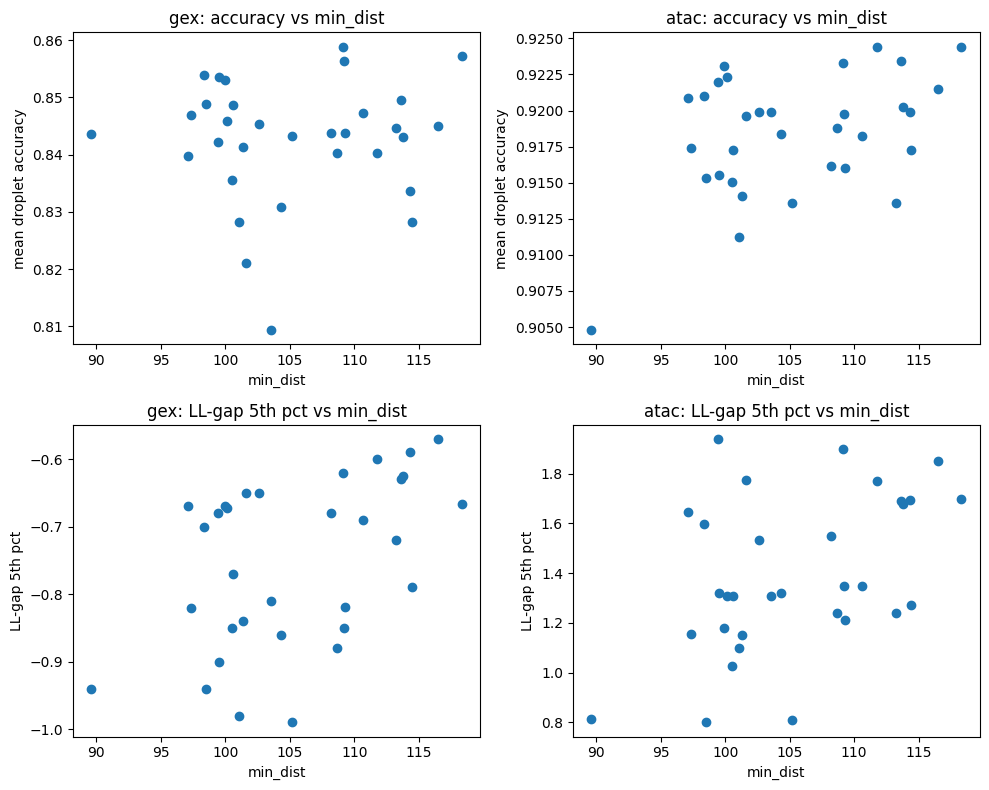

In [11]:
### quick plots: margin/accuracy vs min_dist, per modality
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, modality in enumerate(['gex', 'atac']):
    sub = summary[summary['modality'] == modality]
    axes[0, col].scatter(sub['min_dist'], sub['accuracy'])
    axes[0, col].set_title(f'{modality}: accuracy vs min_dist')
    axes[0, col].set_xlabel('min_dist'); axes[0, col].set_ylabel('mean droplet accuracy')

    axes[1, col].scatter(sub['min_dist'], sub['ll_gap_p5'])
    axes[1, col].set_title(f'{modality}: LL-gap 5th pct vs min_dist')
    axes[1, col].set_xlabel('min_dist'); axes[1, col].set_ylabel('LL-gap 5th pct')
plt.tight_layout()
plt.show()

In [12]:
### write pool-level summary checkpoint
outdir = f'{projdir}/csv/ambisim'
summary.to_csv(f'{outdir}/pool_summary.csv', sep='\t', index=False)

In [13]:
!date

Sun Sep  6 12:21:10 PDT 2026
